In [3]:
# =========================================================
# HW08-09
# PyTorch 101: MLP, Dropout, BatchNorm, EarlyStopping,
# Adam vs SGD+momentum, weight decay
# Датасет: CIFAR10
# =========================================================

import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

In [4]:
# ---------------------------------------------------------
# Фиксируем seed для воспроизводимости
# ---------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ---------------------------------------------------------
# Устройство: GPU, если доступен, иначе CPU
# ---------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [5]:
# ---------------------------------------------------------
# Папки под артефакты
# ---------------------------------------------------------
BASE_DIR = Path(".")
ART_DIR = BASE_DIR / "artifacts"
FIG_DIR = ART_DIR / "figures"

ART_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Artifacts dir:", ART_DIR.resolve())
print("Figures dir:", FIG_DIR.resolve())

Artifacts dir: C:\Users\Elek1\github\Digital-competencies_Seminar_engineering-\homeworks\HW08-09\artifacts
Figures dir: C:\Users\Elek1\github\Digital-competencies_Seminar_engineering-\homeworks\HW08-09\artifacts\figures


In [6]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# ---------------------------------------------------------
# CIFAR10 через torchvision
# ---------------------------------------------------------
transform = transforms.ToTensor()

train_dataset_full = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# ---------------------------------------------------------
# Train / Val split
# ---------------------------------------------------------
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(
    train_dataset_full,
    [train_size, val_size],
    generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# ---------------------------------------------------------
# Sanity-check
# ---------------------------------------------------------
xb, yb = next(iter(train_loader))
print("xb.shape:", xb.shape)
print("yb.shape:", yb.shape)
print("xb min/max:", xb.min().item(), xb.max().item())
print("yb[:10]:", yb[:10])

c:\Users\Elek1\github\Digital-competencies_Seminar_engineering-\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


xb.shape: torch.Size([64, 3, 32, 32])
yb.shape: torch.Size([64])
xb min/max: 0.0 1.0
yb[:10]: tensor([3, 3, 4, 6, 0, 7, 3, 3, 8, 4])


In [7]:
# ---------------------------------------------------------
# MLP-модель для CIFAR10
# Вход: 3 x 32 x 32 = 3072 признака
# ---------------------------------------------------------
class MLP(nn.Module):
    def __init__(self, input_dim=3*32*32, num_classes=10,
                 hidden_sizes=(512, 256),
                 dropout=0.0,
                 use_batchnorm=False):
        super().__init__()

        layers = [nn.Flatten()]
        in_features = input_dim

        for h in hidden_sizes:
            layers.append(nn.Linear(in_features, h))

            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))

            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            in_features = h

        layers.append(nn.Linear(in_features, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [8]:
# ---------------------------------------------------------
# Проверка forward pass
# ---------------------------------------------------------
model = MLP().to(device)

xb, yb = next(iter(train_loader))
xb, yb = xb.to(device), yb.to(device)

logits = model(xb)
print("logits.shape:", logits.shape)   # ожидается [batch, 10]

logits.shape: torch.Size([64, 10])


In [9]:
# ---------------------------------------------------------
# Одна эпоха обучения
# ---------------------------------------------------------
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_samples += xb.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc

In [10]:
# ---------------------------------------------------------
# Оценка модели на val / test
# Обязательно model.eval() и torch.no_grad()
# ---------------------------------------------------------
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_samples += xb.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc

In [11]:
# ---------------------------------------------------------
# Функция построения графиков train/val loss и accuracy
# ---------------------------------------------------------
def plot_history(history, title, save_path=None):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title}: Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title}: Accuracy")
    plt.legend()

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()

In [12]:
# ---------------------------------------------------------
# Универсальная функция запуска одного эксперимента
# ---------------------------------------------------------
def run_experiment(
    experiment_id,
    model_kwargs,
    optimizer_name="Adam",
    lr=1e-3,
    momentum=0.0,
    weight_decay=0.0,
    epochs=10,
    early_stopping=False,
    patience=4,
):
    model = MLP(**model_kwargs).to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )
    elif optimizer_name == "SGD":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=momentum,
            weight_decay=weight_decay
        )
    else:
        raise ValueError("Unsupported optimizer")

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_val_acc = -1.0
    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    wait = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        print(
            f"{experiment_id} | epoch {epoch+1}/{epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

        if early_stopping and wait >= patience:
            print(f"{experiment_id}: early stopping at epoch {epoch+1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    result = {
        "experiment_id": experiment_id,
        "dataset": "CIFAR10",
        "seed": SEED,
        "model_summary": json.dumps(model_kwargs, ensure_ascii=False),
        "optimizer": optimizer_name,
        "lr": lr,
        "momentum": momentum,
        "weight_decay": weight_decay,
        "epochs_trained": len(history["train_loss"]),
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
    }

    return model, history, result

In [13]:
# ---------------------------------------------------------
# График истории обучения
# ---------------------------------------------------------
def plot_history(history, title, save_path=None):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title}: Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title}: Accuracy")
    plt.legend()

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()

In [14]:
# ---------------------------------------------------------
# Универсальный запуск эксперимента
# ---------------------------------------------------------
def run_experiment(
    experiment_id,
    dataset_name,
    model_kwargs,
    optimizer_name="Adam",
    lr=1e-3,
    momentum=0.0,
    weight_decay=0.0,
    epochs=10,
    early_stopping=False,
    patience=4,
):
    model = MLP(**model_kwargs).to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )
    elif optimizer_name == "SGD":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=momentum,
            weight_decay=weight_decay
        )
    else:
        raise ValueError("Unsupported optimizer")

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_val_acc = -1.0
    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0

    wait = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        improved = val_acc > best_val_acc
        if improved:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        print(
            f"{experiment_id} | epoch {epoch+1}/{epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

        if early_stopping and wait >= patience:
            print(f"{experiment_id}: early stopping at epoch {epoch+1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    result = {
        "experiment_id": experiment_id,
        "dataset": dataset_name,
        "seed": SEED,
        "model_summary": json.dumps(model_kwargs, ensure_ascii=False),
        "optimizer": optimizer_name,
        "lr": lr,
        "momentum": momentum,
        "weight_decay": weight_decay,
        "epochs_trained": len(history["train_loss"]),
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
    }

    return model, history, result

In [15]:
# ---------------------------------------------------------
# Контейнеры для результатов всех прогонов
# ---------------------------------------------------------
all_results = []
all_histories = {}
all_models = {}

In [16]:
# ---------------------------------------------------------
# E1: базовая MLP без Dropout и BatchNorm
# ---------------------------------------------------------
E1_kwargs = {
    "hidden_sizes": (512, 256),
    "dropout": 0.0,
    "use_batchnorm": False
}

model_E1, history_E1, result_E1 = run_experiment(
    experiment_id="E1",
    dataset_name="CIFAR10",
    model_kwargs=E1_kwargs,
    optimizer_name="Adam",
    lr=1e-3,
    weight_decay=0.0,
    epochs=10
)

all_results.append(result_E1)
all_histories["E1"] = history_E1
all_models["E1"] = model_E1

E1 | epoch 1/10 | train_loss=1.8674 train_acc=0.3179 | val_loss=1.7327 val_acc=0.3757
E1 | epoch 2/10 | train_loss=1.6897 train_acc=0.3908 | val_loss=1.6475 val_acc=0.4096
E1 | epoch 3/10 | train_loss=1.6077 train_acc=0.4254 | val_loss=1.5851 val_acc=0.4383
E1 | epoch 4/10 | train_loss=1.5447 train_acc=0.4480 | val_loss=1.5755 val_acc=0.4379
E1 | epoch 5/10 | train_loss=1.5044 train_acc=0.4630 | val_loss=1.5160 val_acc=0.4620
E1 | epoch 6/10 | train_loss=1.4685 train_acc=0.4757 | val_loss=1.4820 val_acc=0.4653
E1 | epoch 7/10 | train_loss=1.4441 train_acc=0.4848 | val_loss=1.4763 val_acc=0.4725
E1 | epoch 8/10 | train_loss=1.4166 train_acc=0.4943 | val_loss=1.4632 val_acc=0.4869
E1 | epoch 9/10 | train_loss=1.3925 train_acc=0.5008 | val_loss=1.4704 val_acc=0.4715
E1 | epoch 10/10 | train_loss=1.3711 train_acc=0.5104 | val_loss=1.4522 val_acc=0.4882


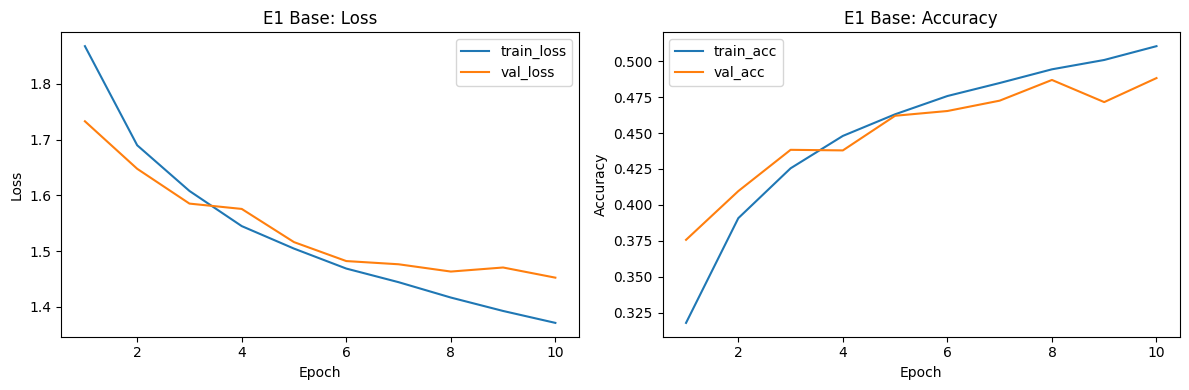

In [17]:
plot_history(history_E1, "E1 Base")

In [18]:
# ---------------------------------------------------------
# E2: MLP с Dropout
# ---------------------------------------------------------
E2_kwargs = {
    "hidden_sizes": (512, 256),
    "dropout": 0.3,
    "use_batchnorm": False
}

model_E2, history_E2, result_E2 = run_experiment(
    experiment_id="E2",
    dataset_name="CIFAR10",
    model_kwargs=E2_kwargs,
    optimizer_name="Adam",
    lr=1e-3,
    weight_decay=0.0,
    epochs=10
)

all_results.append(result_E2)
all_histories["E2"] = history_E2
all_models["E2"] = model_E2


E2 | epoch 1/10 | train_loss=1.9845 train_acc=0.2685 | val_loss=1.8346 val_acc=0.3230
E2 | epoch 2/10 | train_loss=1.8563 train_acc=0.3241 | val_loss=1.7465 val_acc=0.3745
E2 | epoch 3/10 | train_loss=1.8060 train_acc=0.3434 | val_loss=1.7155 val_acc=0.3848
E2 | epoch 4/10 | train_loss=1.7739 train_acc=0.3569 | val_loss=1.6588 val_acc=0.4096
E2 | epoch 5/10 | train_loss=1.7401 train_acc=0.3725 | val_loss=1.6521 val_acc=0.4233
E2 | epoch 6/10 | train_loss=1.7362 train_acc=0.3716 | val_loss=1.6622 val_acc=0.4196
E2 | epoch 7/10 | train_loss=1.7126 train_acc=0.3841 | val_loss=1.6438 val_acc=0.4232
E2 | epoch 8/10 | train_loss=1.6973 train_acc=0.3872 | val_loss=1.6598 val_acc=0.4107
E2 | epoch 9/10 | train_loss=1.6966 train_acc=0.3887 | val_loss=1.6429 val_acc=0.4245
E2 | epoch 10/10 | train_loss=1.6783 train_acc=0.3955 | val_loss=1.6303 val_acc=0.4263


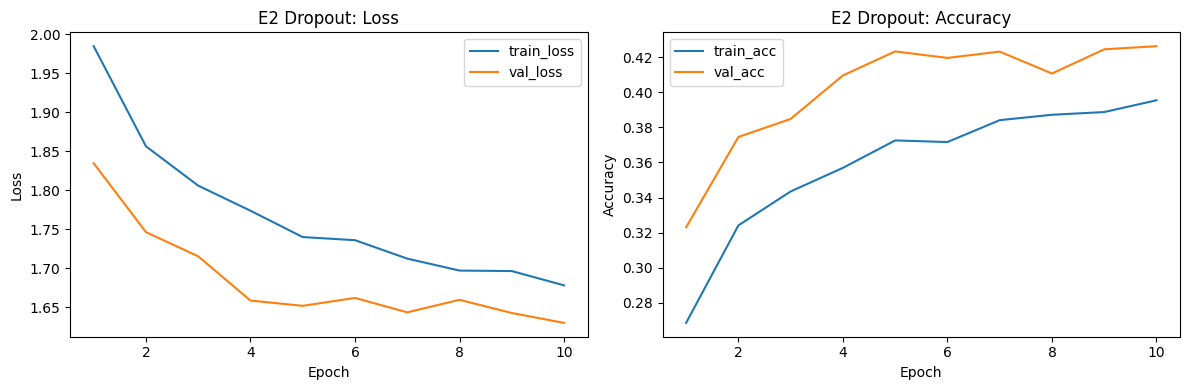

In [19]:
plot_history(history_E2, "E2 Dropout")

In [20]:
# ---------------------------------------------------------
# E3: BatchNorm
# ---------------------------------------------------------
E3_kwargs = {
    "hidden_sizes": (256, 128),
    "dropout": 0.0,
    "use_batchnorm": True
}

model_E3, history_E3, result_E3 = run_experiment(
    experiment_id="E3",
    dataset_name="synthetic",
    model_kwargs=E3_kwargs,
    optimizer_name="Adam",
    lr=1e-3,
    weight_decay=0.0,
    epochs=10
)

all_results.append(result_E3)
all_histories["E3"] = history_E3
all_models["E3"] = model_E3

E3 | epoch 1/10 | train_loss=1.6441 train_acc=0.4100 | val_loss=1.6383 val_acc=0.4127
E3 | epoch 2/10 | train_loss=1.4325 train_acc=0.4867 | val_loss=1.5205 val_acc=0.4638
E3 | epoch 3/10 | train_loss=1.3250 train_acc=0.5287 | val_loss=1.4165 val_acc=0.4969
E3 | epoch 4/10 | train_loss=1.2485 train_acc=0.5549 | val_loss=1.4545 val_acc=0.4903
E3 | epoch 5/10 | train_loss=1.1855 train_acc=0.5777 | val_loss=1.3999 val_acc=0.5111
E3 | epoch 6/10 | train_loss=1.1257 train_acc=0.5985 | val_loss=1.4064 val_acc=0.5164
E3 | epoch 7/10 | train_loss=1.0685 train_acc=0.6227 | val_loss=1.5450 val_acc=0.4653
E3 | epoch 8/10 | train_loss=1.0110 train_acc=0.6397 | val_loss=1.4582 val_acc=0.5057
E3 | epoch 9/10 | train_loss=0.9655 train_acc=0.6561 | val_loss=1.4877 val_acc=0.5030
E3 | epoch 10/10 | train_loss=0.9206 train_acc=0.6730 | val_loss=1.5266 val_acc=0.5018


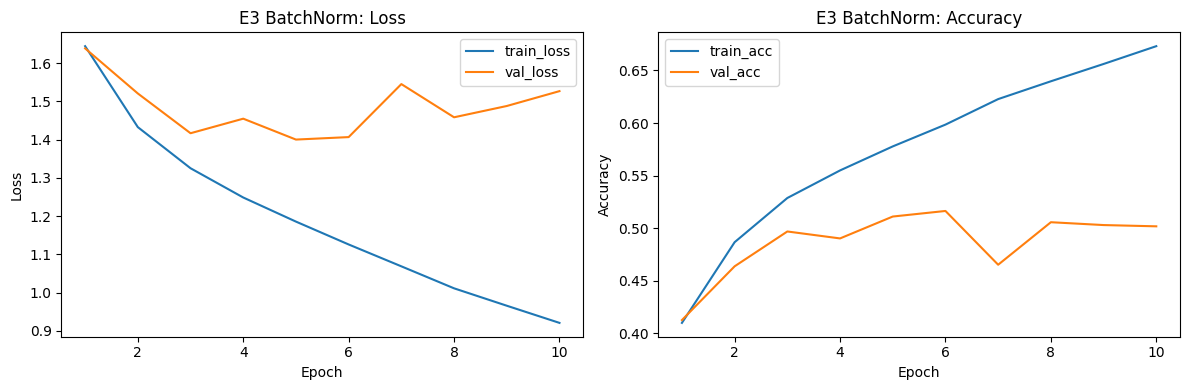

In [21]:
plot_history(history_E3, "E3 BatchNorm")

In [22]:
# ---------------------------------------------------------
# Выбираем лучший результат между E2 и E3 по val_accuracy
# ---------------------------------------------------------
candidates = [result_E2, result_E3]
best_pre_es = max(candidates, key=lambda x: x["best_val_accuracy"])

print("Best between E2 and E3:", best_pre_es["experiment_id"])
best_pre_es


Best between E2 and E3: E3


{'experiment_id': 'E3',
 'dataset': 'synthetic',
 'seed': 42,
 'model_summary': '{"hidden_sizes": [256, 128], "dropout": 0.0, "use_batchnorm": true}',
 'optimizer': 'Adam',
 'lr': 0.001,
 'momentum': 0.0,
 'weight_decay': 0.0,
 'epochs_trained': 10,
 'best_val_accuracy': 0.5164,
 'best_val_loss': 1.4064004640579224,
 'best_epoch': 6}

In [24]:
if best_pre_es["experiment_id"] == "E2":
    E4_kwargs = E2_kwargs
else:
    E4_kwargs = E3_kwargs

model_E4, history_E4, result_E4 = run_experiment(
    experiment_id="E4",
    dataset_name="CIFAR10",
    model_kwargs=E4_kwargs,
    optimizer_name="Adam",
    lr=1e-3,
    weight_decay=0.0,
    epochs=20,
    early_stopping=True,
    patience=4
)

all_results.append(result_E4)
all_histories["E4"] = history_E4
all_models["E4"] = model_E4


E4 | epoch 1/20 | train_loss=1.6377 train_acc=0.4168 | val_loss=1.7499 val_acc=0.3668
E4 | epoch 2/20 | train_loss=1.4312 train_acc=0.4881 | val_loss=1.4848 val_acc=0.4699
E4 | epoch 3/20 | train_loss=1.3314 train_acc=0.5252 | val_loss=1.4868 val_acc=0.4764
E4 | epoch 4/20 | train_loss=1.2526 train_acc=0.5521 | val_loss=1.3548 val_acc=0.5231
E4 | epoch 5/20 | train_loss=1.1831 train_acc=0.5766 | val_loss=1.6286 val_acc=0.4518
E4 | epoch 6/20 | train_loss=1.1214 train_acc=0.6029 | val_loss=1.4171 val_acc=0.5032
E4 | epoch 7/20 | train_loss=1.0627 train_acc=0.6209 | val_loss=1.3315 val_acc=0.5353
E4 | epoch 8/20 | train_loss=1.0117 train_acc=0.6404 | val_loss=1.3596 val_acc=0.5325
E4 | epoch 9/20 | train_loss=0.9631 train_acc=0.6573 | val_loss=1.3889 val_acc=0.5297
E4 | epoch 10/20 | train_loss=0.9035 train_acc=0.6768 | val_loss=1.5615 val_acc=0.5007
E4 | epoch 11/20 | train_loss=0.8674 train_acc=0.6921 | val_loss=1.5760 val_acc=0.4936
E4: early stopping at epoch 11


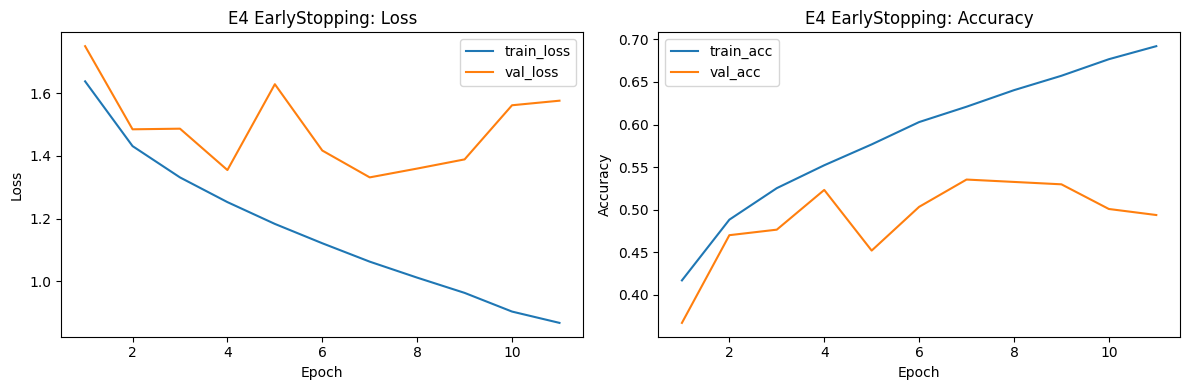

In [25]:
plot_history(history_E4, "E4 EarlyStopping", FIG_DIR / "curves_best.png")

In [26]:
# ---------------------------------------------------------
# Сохраняем лучшую модель домашки (E4)
# ---------------------------------------------------------
best_model = model_E4
best_config = {
    "dataset": "synthetic",
    "seed": SEED,
    "model_kwargs": E4_kwargs,
    "optimizer": "Adam",
    "lr": 1e-3,
    "weight_decay": 0.0,
    "early_stopping": True,
    "patience": 4
}

torch.save(best_model.state_dict(), ART_DIR / "best_model.pt")

with open(ART_DIR / "best_config.json", "w", encoding="utf-8") as f:
    json.dump(best_config, f, ensure_ascii=False, indent=2)

print("Saved best_model.pt and best_config.json")

Saved best_model.pt and best_config.json


In [28]:
# ---------------------------------------------------------
# O1: слишком большой learning rate
# ---------------------------------------------------------
model_O1, history_O1, result_O1 = run_experiment(
    experiment_id="O1",
    dataset_name="CIFAR10",
    model_kwargs=E4_kwargs,
    optimizer_name="Adam",
    lr=1e-1,
    weight_decay=0.0,
    epochs=6
)

all_results.append(result_O1)
all_histories["O1"] = history_O1
all_models["O1"] = model_O1


O1 | epoch 1/6 | train_loss=1.8656 train_acc=0.3237 | val_loss=1.8172 val_acc=0.3539
O1 | epoch 2/6 | train_loss=1.6837 train_acc=0.3893 | val_loss=1.6504 val_acc=0.4083
O1 | epoch 3/6 | train_loss=1.6196 train_acc=0.4163 | val_loss=1.6257 val_acc=0.4124
O1 | epoch 4/6 | train_loss=1.5615 train_acc=0.4412 | val_loss=1.7921 val_acc=0.3741
O1 | epoch 5/6 | train_loss=1.5222 train_acc=0.4532 | val_loss=1.7573 val_acc=0.3827
O1 | epoch 6/6 | train_loss=1.4818 train_acc=0.4647 | val_loss=1.5609 val_acc=0.4394


In [29]:
# ---------------------------------------------------------
# O2: слишком маленький learning rate
# ---------------------------------------------------------
model_O2, history_O2, result_O2 = run_experiment(
    experiment_id="O2",
    dataset_name="CIFAR10",
    model_kwargs=E4_kwargs,
    optimizer_name="Adam",
    lr=1e-5,
    weight_decay=0.0,
    epochs=6
)

all_results.append(result_O2)
all_histories["O2"] = history_O2
all_models["O2"] = model_O2


O2 | epoch 1/6 | train_loss=1.9782 train_acc=0.3121 | val_loss=1.8313 val_acc=0.3871
O2 | epoch 2/6 | train_loss=1.7724 train_acc=0.4054 | val_loss=1.7270 val_acc=0.4184
O2 | epoch 3/6 | train_loss=1.6866 train_acc=0.4371 | val_loss=1.6674 val_acc=0.4426
O2 | epoch 4/6 | train_loss=1.6284 train_acc=0.4562 | val_loss=1.6245 val_acc=0.4548
O2 | epoch 5/6 | train_loss=1.5830 train_acc=0.4713 | val_loss=1.5935 val_acc=0.4603
O2 | epoch 6/6 | train_loss=1.5409 train_acc=0.4845 | val_loss=1.5668 val_acc=0.4750


In [30]:
# ---------------------------------------------------------
# O3: SGD + momentum + weight decay
# ---------------------------------------------------------
model_O3, history_O3, result_O3 = run_experiment(
    experiment_id="O3",
    dataset_name="CIFAR10",
    model_kwargs=E4_kwargs,
    optimizer_name="SGD",
    lr=1e-2,
    momentum=0.9,
    weight_decay=1e-4,
    epochs=12
)

all_results.append(result_O3)
all_histories["O3"] = history_O3
all_models["O3"] = model_O3


O3 | epoch 1/12 | train_loss=1.6442 train_acc=0.4118 | val_loss=1.6327 val_acc=0.4247
O3 | epoch 2/12 | train_loss=1.4331 train_acc=0.4884 | val_loss=1.5108 val_acc=0.4610
O3 | epoch 3/12 | train_loss=1.3311 train_acc=0.5236 | val_loss=1.4326 val_acc=0.4887
O3 | epoch 4/12 | train_loss=1.2548 train_acc=0.5517 | val_loss=1.4577 val_acc=0.4893
O3 | epoch 5/12 | train_loss=1.1922 train_acc=0.5757 | val_loss=1.4648 val_acc=0.5015
O3 | epoch 6/12 | train_loss=1.1296 train_acc=0.5972 | val_loss=1.5670 val_acc=0.4690
O3 | epoch 7/12 | train_loss=1.0874 train_acc=0.6147 | val_loss=1.4469 val_acc=0.5069
O3 | epoch 8/12 | train_loss=1.0318 train_acc=0.6332 | val_loss=1.3883 val_acc=0.5166
O3 | epoch 9/12 | train_loss=0.9904 train_acc=0.6463 | val_loss=1.3987 val_acc=0.5177
O3 | epoch 10/12 | train_loss=0.9547 train_acc=0.6577 | val_loss=1.5526 val_acc=0.4866
O3 | epoch 11/12 | train_loss=0.9111 train_acc=0.6779 | val_loss=1.5389 val_acc=0.4978
O3 | epoch 12/12 | train_loss=0.8706 train_acc=0.691

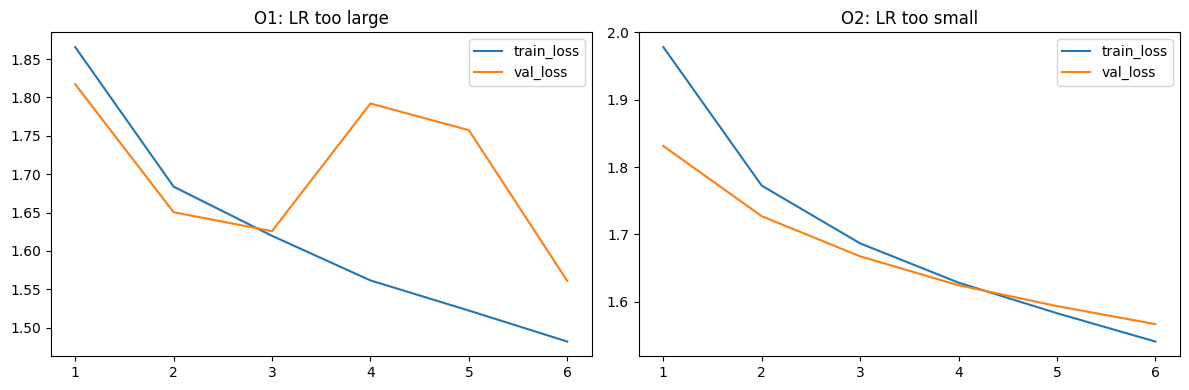

In [31]:
epochs_o1 = range(1, len(history_O1["train_loss"]) + 1)
epochs_o2 = range(1, len(history_O2["train_loss"]) + 1)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(epochs_o1, history_O1["train_loss"], label="train_loss")
plt.plot(epochs_o1, history_O1["val_loss"], label="val_loss")
plt.title("O1: LR too large")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_o2, history_O2["train_loss"], label="train_loss")
plt.plot(epochs_o2, history_O2["val_loss"], label="val_loss")
plt.title("O2: LR too small")
plt.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "curves_lr_extremes.png")
plt.show()


In [32]:
# ---------------------------------------------------------
# Финальная оценка лучшей модели на test
# ---------------------------------------------------------
criterion = nn.CrossEntropyLoss()

test_loss, test_acc = evaluate(model_E4, test_loader, criterion, device)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)


Test loss: 1.3493619918823243
Test accuracy: 0.5223


In [33]:
# ---------------------------------------------------------
# Таблица всех экспериментов
# ---------------------------------------------------------
runs_df = pd.DataFrame(all_results)
runs_df.to_csv(ART_DIR / "runs.csv", index=False)

runs_df


,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss,best_epoch
0,E1,CIFAR10,42,"{""hidden_sizes"": [512, 256], ""dropout"": 0.0, ""...",Adam,0.00100,0.0,0.0000,10,0.4882,1.452231,10
1,E2,CIFAR10,42,"{""hidden_sizes"": [512, 256], ""dropout"": 0.3, ""...",Adam,0.00100,0.0,0.0000,10,0.4263,1.630292,10
2,E3,synthetic,42,"{""hidden_sizes"": [256, 128], ""dropout"": 0.0, ""...",Adam,0.00100,0.0,0.0000,10,0.5164,1.406400,6
3,E4,CIFAR10,42,"{""hidden_sizes"": [256, 128], ""dropout"": 0.0, ""...",Adam,0.00100,0.0,0.0000,11,0.5353,1.331477,7
4,O1,CIFAR10,42,"{""hidden_sizes"": [256, 128], ""dropout"": 0.0, ""...",Adam,0.10000,0.0,0.0000,6,0.4394,1.560855,6
5,O2,CIFAR10,42,"{""hidden_sizes"": [256, 128], ""dropout"": 0.0, ""...",Adam,0.00001,0.0,0.0000,6,0.4750,1.566777,6
6,O3,CIFAR10,42,"{""hidden_sizes"": [256, 128], ""dropout"": 0.0, ""...",SGD,0.01000,0.9,0.0001,12,0.5178,1.465268,12


In [34]:
# ---------------------------------------------------------
# Проверяем, что всё сохранилось
# ---------------------------------------------------------
for p in sorted(ART_DIR.rglob("*")):
    print(p)


artifacts\best_config.json
artifacts\best_model.pt
artifacts\figures
artifacts\figures\curves_best.png
artifacts\figures\curves_lr_extremes.png
artifacts\runs.csv
